This data set focuses music and its effects on variables such as reaction time, mood, arousal, and thought probe

Order of plots,
Analysis on boxplot of reaction time,
analysis on plots of arousal and mood
analysis on plot of thought probe
analysis of three different confusion matrices

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import scipy

FILE_PATH = "../../data/01-interim/KL_Dataset_cleaned.csv"
df = pd.read_csv(FILE_PATH)

df.columns = df.columns.str.strip()
df.head()


,ID,Reaction time,No-go trial,Thought probe,Arousal,Mood,trial number,block number,Music-present,presentation order,experiment
0,1,0.358835,NaN,NaN,NaN,NaN,1,1,True,True,1
1,1,0.545465,NaN,NaN,NaN,NaN,2,1,True,True,1
2,1,0.425985,1.0,NaN,NaN,NaN,3,1,True,True,1
3,1,0.472115,NaN,NaN,NaN,NaN,4,1,True,True,1
4,1,0.623765,NaN,NaN,NaN,NaN,5,1,True,True,1


## Shape and Information of the KL Dataset

The following output displays the shape, info(), describe(), and summation of null answers for each column.

In [13]:
df.shape
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62220 entries, 0 to 62219
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  62220 non-null  int64  
 1   Reaction time       60571 non-null  float64
 2   No-go trial         5490 non-null   float64
 3   Thought probe       10980 non-null  float64
 4   Arousal             10980 non-null  float64
 5   Mood                10980 non-null  float64
 6   trial number        62220 non-null  int64  
 7   block number        62220 non-null  int64  
 8   Music-present       62220 non-null  bool   
 9   presentation order  62220 non-null  bool   
 10  experiment          62220 non-null  int64  
dtypes: bool(2), float64(5), int64(4)
memory usage: 4.4 MB


ID                        0
Reaction time          1649
No-go trial           56730
Thought probe         51240
Arousal               51240
Mood                  51240
trial number              0
block number              0
Music-present             0
presentation order        0
experiment                0
dtype: int64

In [14]:
df['Music-present'].value_counts()

Music-present
True     31110
False    31110
Name: count, dtype: int64

## Reaction Time Boxplot

There is a considerable amount of outliers present in the data, ranging from almost 0ms to 100+ms. To narrow down the range of data for the sake of visualization, the following boxplots are for reaction times less than 10ms.

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


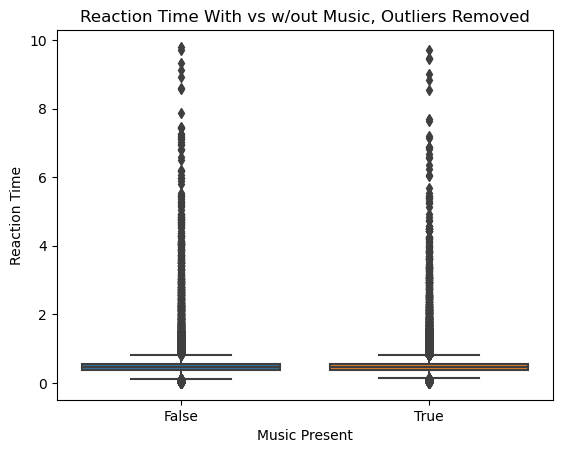

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


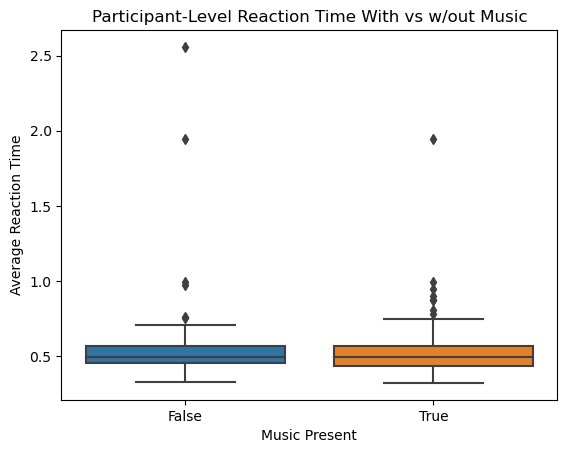

In [15]:
rt_clean = df[df['Reaction time'] < 10]

sns.boxplot(
    data=rt_clean,
    x='Music-present',
    y='Reaction time'
)

plt.xlabel("Music Present")
plt.ylabel("Reaction Time")
plt.title("Reaction Time With vs w/out Music, Outliers Removed")
plt.show()

participant_rt = (
    rt_clean
    .groupby(['ID', 'Music-present'])['Reaction time']
    .mean()
    .reset_index()
)

sns.boxplot(
    data=participant_rt,
    x='Music-present',
    y='Reaction time'
)

plt.xlabel("Music Present")
plt.ylabel("Average Reaction Time")
plt.title("Participant-Level Reaction Time With vs w/out Music")
plt.show()



# Log Transformation of Reaction Time

Reaction time is right-skewed due to a long tail of slow responses. A log transformation compresses that tail and pulls the distribution closer to normal, which helps downstream modeling and statistical tests that assume normality.

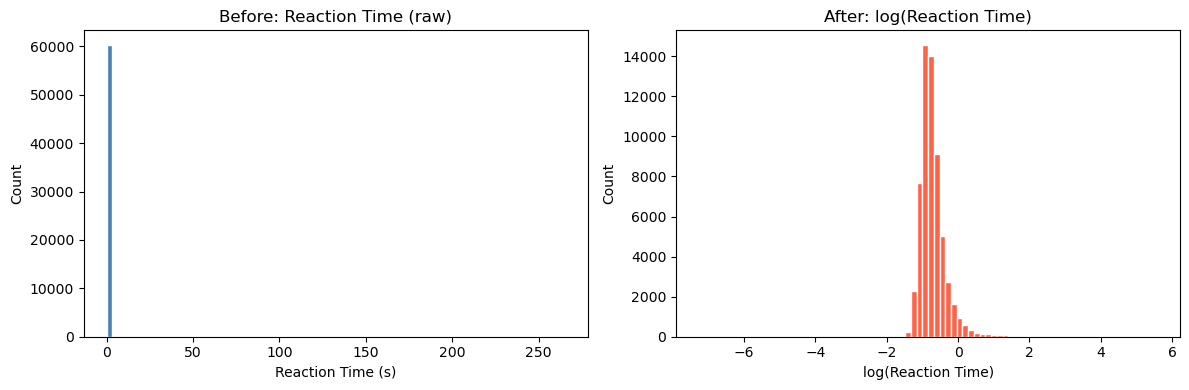

Raw  — skewness: 85.567,  mean: 0.5638,  std: 2.2088
Log  — skewness: 0.279,  mean: -0.7330, std: 0.4258


In [16]:
rt = df['Reaction time'].dropna()
rt_positive = rt[rt > 0]
rt_log = np.log(rt_positive)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rt_positive, bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Reaction Time (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Before: Reaction Time (raw)')

axes[1].hist(rt_log, bins=80, color='tomato', edgecolor='white')
axes[1].set_xlabel('log(Reaction Time)')
axes[1].set_ylabel('Count')
axes[1].set_title('After: log(Reaction Time)')

plt.tight_layout()
plt.show()

print(f"Raw  — skewness: {rt_positive.skew():.3f},  mean: {rt_positive.mean():.4f},  std: {rt_positive.std():.4f}")
print(f"Log  — skewness: {rt_log.skew():.3f},  mean: {rt_log.mean():.4f}, std: {rt_log.std():.4f}")

The first plot shows the reaction time of participants with reaction time cutoff after 10ms with and without music, we cut off data after 10ms because of the existence of large outliers likely being negligible. To account for any outliers in our analysis we produced a second plot that shows the average reaction time of participants (based off participant ID) with and without music. 

It appears that when looking at the two respective boxplots, the medians are close and the distributions in general for music and no music conditions are very similar. We can conclude that music does not appear to have a significant effect on reaction time or average reaction time.


## Log Reaction Time by Music Condition

Now that we've compressed the right tail with a log transformation, we can compare the full shape of the RT distribution between music and no-music trials. Extreme outliers (RT > 10 s) are excluded to match the cleaning convention used in the boxplots above.

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.

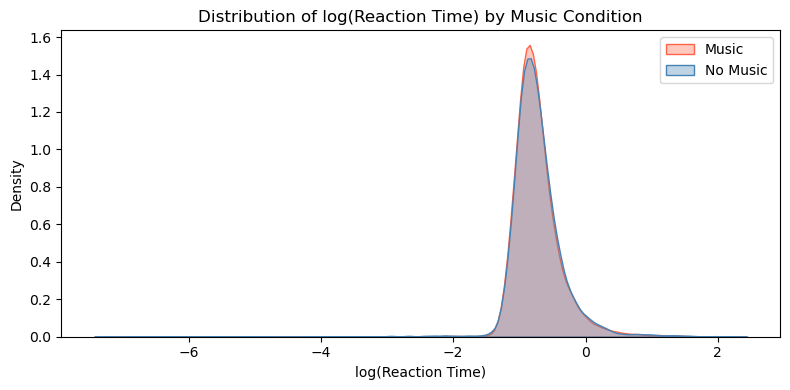

Music: mean=-0.7372, std=0.3947, skew=-0.149
No Music: mean=-0.7340, std=0.4288, skew=-0.669


In [17]:
rt_filtered = df[(df['Reaction time'] > 0) & (df['Reaction time'] < 10)].copy()
rt_filtered['log_RT'] = np.log(rt_filtered['Reaction time'])

fig, ax = plt.subplots(figsize=(8, 4))
for present, label, color in [(True, 'Music', 'tomato'), (False, 'No Music', 'steelblue')]:
    subset = rt_filtered[rt_filtered['Music-present'] == present]['log_RT']
    sns.kdeplot(subset, ax=ax, label=label, color=color, fill=True, alpha=0.35)

ax.set_xlabel('log(Reaction Time)')
ax.set_ylabel('Density')
ax.set_title('Distribution of log(Reaction Time) by Music Condition')
ax.legend()
plt.tight_layout()
plt.show()

for present, label in [(True, 'Music'), (False, 'No Music')]:
    vals = rt_filtered[rt_filtered['Music-present'] == present]['log_RT']
    print(f"{label}: mean={vals.mean():.4f}, std={vals.std():.4f}, skew={vals.skew():.3f}")

## Mood, Arousal, and Thought Probe — Violin Plots

Violin plots show the full distribution shape, not just the median and IQR. Each violin is mirrored kernel density, with the inner box showing the quartile range. This lets us see whether the distributions are unimodal, skewed, or have clusters — information a boxplot hides.

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

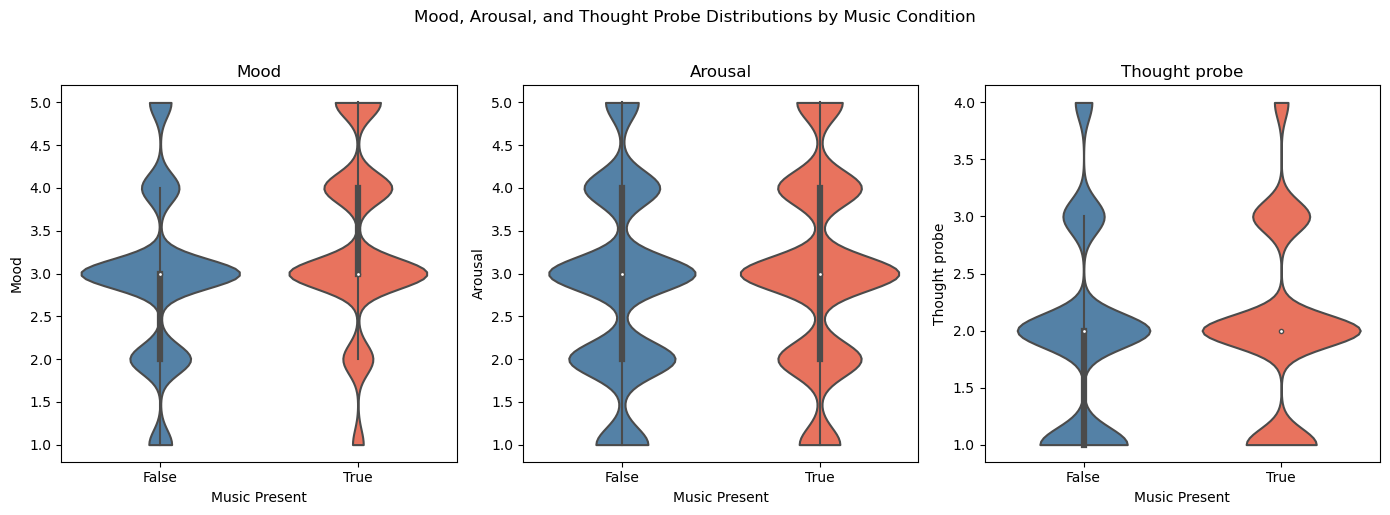

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, var in zip(axes, ['Mood', 'Arousal', 'Thought probe']):
    sns.violinplot(
        data=df,
        x='Music-present',
        y=var,
        ax=ax,
        palette={False: 'steelblue', True: 'tomato'},
        inner='box',
        cut=0
    )
    ax.set_xlabel('Music Present')
    ax.set_title(var)

fig.suptitle('Mood, Arousal, and Thought Probe Distributions by Music Condition', y=1.02)
plt.tight_layout()
plt.show()

## Feature Correlation Heatmap

A Pearson correlation matrix across all continuous outcome measures shows which variables move together. We include both raw and log-transformed Reaction Time to see whether the transformation changes its relationship with the other features. Only rows where all four original features are non-null are used (the thought-probe subset).

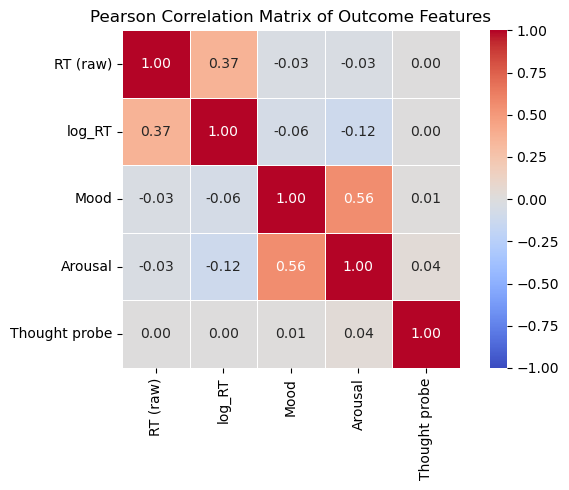

In [19]:
corr_df = df[['Reaction time', 'Mood', 'Arousal', 'Thought probe']].dropna().copy()
corr_df = corr_df[corr_df['Reaction time'] > 0]
corr_df['log_RT'] = np.log(corr_df['Reaction time'])
corr_df = corr_df.rename(columns={'Reaction time': 'RT (raw)'})

corr_matrix = corr_df[['RT (raw)', 'log_RT', 'Mood', 'Arousal', 'Thought probe']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Pearson Correlation Matrix of Outcome Features')
plt.tight_layout()
plt.show()

## Reaction Time Progression Across Blocks

The experiment is divided into blocks. If participants get faster over time (practice effect) or slower (fatigue), that will show up as a trend in mean RT per block. If music helps, we'd expect the music condition to show a smaller increase in RT across blocks. This is the first look at the temporal structure of the data.

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

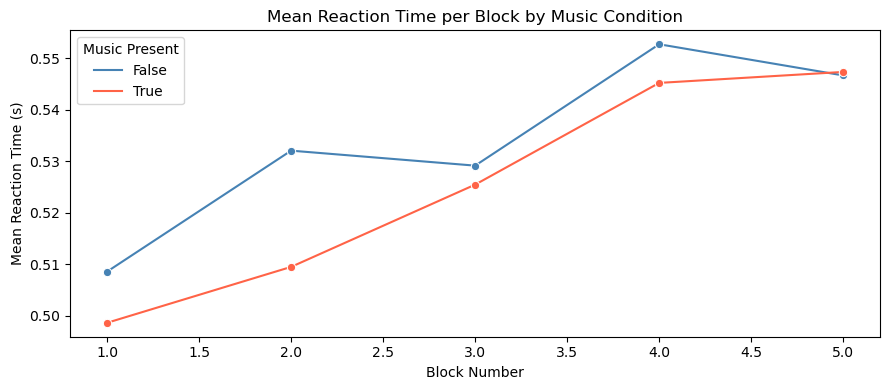

Blocks present: [1, 2, 3, 4, 5]
Total blocks: 5


In [20]:
block_rt = (
    rt_clean
    .groupby(['block number', 'Music-present'])['Reaction time']
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 4))
sns.lineplot(
    data=block_rt,
    x='block number',
    y='Reaction time',
    hue='Music-present',
    palette={True: 'tomato', False: 'steelblue'},
    marker='o'
)
plt.xlabel('Block Number')
plt.ylabel('Mean Reaction Time (s)')
plt.title('Mean Reaction Time per Block by Music Condition')
plt.legend(title='Music Present')
plt.tight_layout()
plt.show()

print("Blocks present:", sorted(rt_clean['block number'].unique()))
print("Total blocks:", rt_clean['block number'].nunique())

## No-Go Trial Error Rate by Music Condition

No-go trials are trials where participants were instructed *not* to respond. A response on a no-go trial is an **inhibition failure** — the participant couldn't suppress their reaction. A value of `1.0` in the `No-go trial` column marks a failure; `0.0` marks a successful inhibition. If music distracts participants, we'd expect a higher error rate when music is present.

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


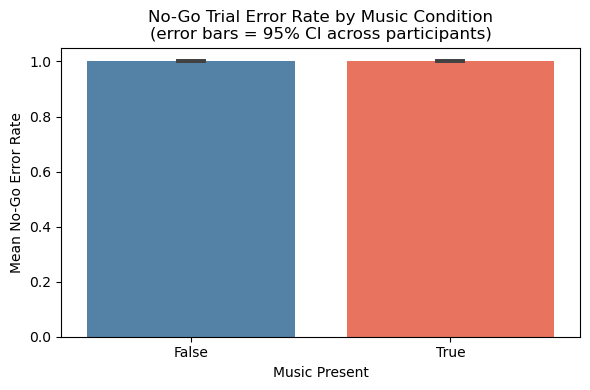

Music: mean error rate = 1.000, n = 115 participants
No Music: mean error rate = 1.000, n = 115 participants


In [21]:
nogo_df = df[df['No-go trial'].notna()].copy()

nogo_summary = (
    nogo_df
    .groupby(['ID', 'Music-present'])['No-go trial']
    .mean()
    .reset_index()
    .rename(columns={'No-go trial': 'error_rate'})
)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=nogo_summary,
    x='Music-present',
    y='error_rate',
    palette={True: 'tomato', False: 'steelblue'},
    capsize=0.1,
    errorbar=('ci', 95)
)
plt.xlabel('Music Present')
plt.ylabel('Mean No-Go Error Rate')
plt.title('No-Go Trial Error Rate by Music Condition\n(error bars = 95% CI across participants)')
plt.ylim(0, None)
plt.tight_layout()
plt.show()

for cond, label in [(True, 'Music'), (False, 'No Music')]:
    rates = nogo_summary[nogo_summary['Music-present'] == cond]['error_rate']
    print(f"{label}: mean error rate = {rates.mean():.3f}, n = {len(rates)} participants")

## Thought Probe 

The dataset contains measurements for thought probe which is the psychological research term where participants are frequently interrupted during a task and are asked to report where there attention is directed and for how long. It essentially measures and maps how our brains focus on tasks and are able to manage our internal or unrelated thoughts.

In [22]:
participant_summary = (
    df
    .dropna(subset=['Mood', 'Arousal', 'Thought probe'])
    .groupby(['ID', 'Music-present'])[['Mood', 'Arousal', 'Thought probe']]
    .mean()
    .reset_index()
)

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


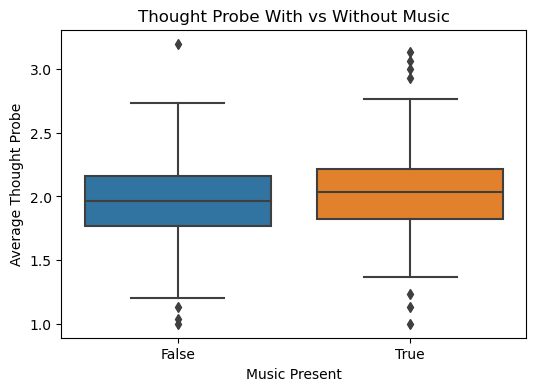

In [23]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=participant_summary,
    x='Music-present',
    y='Thought probe'
)

plt.xlabel("Music Present")
plt.ylabel("Average Thought Probe")
plt.title("Thought Probe With vs Without Music")
plt.show()


Similar to reaction time, we see that thought probe with both conditions is very similar. So we can hypothesize that music does not significantly affect thought probe.

## Mood With vs Without Music

The following graphs display the self-reported score for mood, ranging from 0 to 5.

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


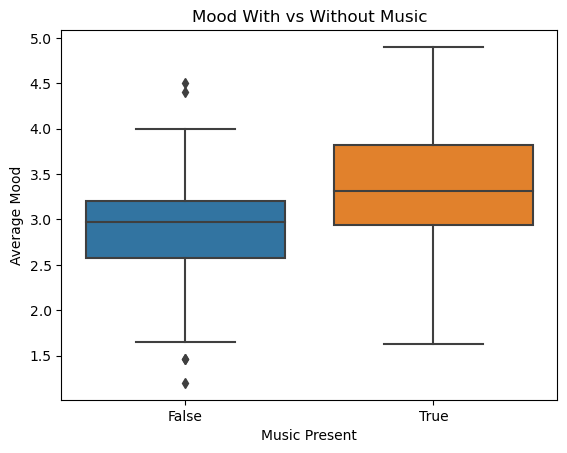

In [24]:

participant_summary.head()


sns.boxplot(
    data=participant_summary,
    x='Music-present',
    y='Mood'
)

plt.xlabel("Music Present")
plt.ylabel("Average Mood")
plt.title("Mood With vs Without Music")
plt.show()

When music is present mood has a visibly higher median score than the no music condition. There is still some overlap between the groups, but this overall trend suggests a positive association between mood and music.

## Arousal With vs Without Music

The following graphs display the self-reported score for arousal, ranging from 0 to 5.

c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\evanc\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


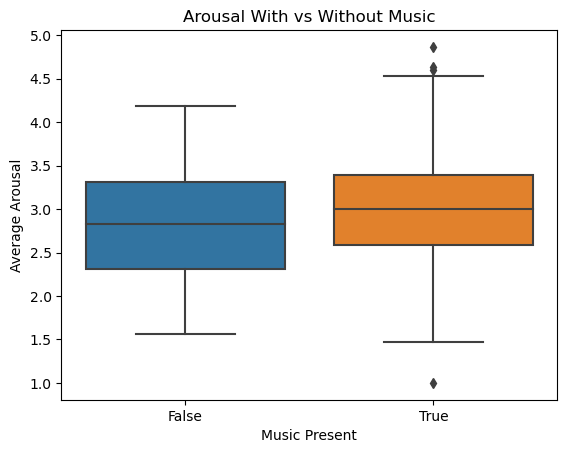

In [25]:

sns.boxplot(
    data=participant_summary,
    x='Music-present',
    y='Arousal'
)

plt.xlabel("Music Present")
plt.ylabel("Average Arousal")
plt.title("Arousal With vs Without Music")
plt.show()

Even with a slightly higher median the boxplots overlap a lot, so music and its effect on arousal is weaker than mood.

In [26]:
df['Thought probe'].value_counts(dropna=False)

summary_table = df.groupby('Music-present')[
    ['Reaction time', 'Mood', 'Arousal', 'Thought probe']
].agg(
    ['mean', 'median', 'std']
)

summary_table

Reaction time                         Mood                   \
                       mean   median       std      mean median       std   
Music-present                                                               
False              0.584898  0.45553  2.589622  2.915118    3.0  0.952549   
True               0.542672  0.45310  1.745790  3.365574    3.0  0.983679   

                Arousal                  Thought probe                   
                   mean median       std          mean median       std  
Music-present                                                            
False          2.832605    3.0  1.110342      1.953370    2.0  0.836634  
True           3.024408    3.0  1.114237      2.047359    2.0  0.778150

This table gives us a numerical summary of what our plotting is generally trying to answer. It groups the data by mean, median, standard deviation for reaction time, mood, arousal, and thought probe. We see that music doesn't generally effect reaction time and thought probe due to the fact that the mean for both conditions were similar. Music does seem to be highly associated with higher mood and higher arousal, with a noticably higher mean.

In [27]:
from scipy.stats import ttest_rel

variables = ['Reaction time', 'Mood', 'Arousal', 'Thought probe']

for var in variables:
    # Optional: use cleaned reaction time only for Reaction time
    if var == 'Reaction time':
        temp_df = df[df['Reaction time'] < 10].copy()
    else:
        temp_df = df.copy()

    # Average each variable by participant and music condition
    summary = (
        temp_df
        .dropna(subset=[var])
        .groupby(['ID', 'Music-present'])[var]
        .mean()
        .reset_index()
    )

    # Make one column for No Music and one for Music
    wide = summary.pivot(
        index='ID',
        columns='Music-present',
        values=var
    )

    wide.columns = ['No_Music', 'Music']
    wide = wide.dropna()

    # Paired t-test
    result = ttest_rel(
        wide['Music'],
        wide['No_Music']
    )

    print(var)
    print(f"No Music mean: {wide['No_Music'].mean():.3f}")
    print(f"Music mean: {wide['Music'].mean():.3f}")
    print(f"t({result.df}) = {result.statistic:.3f}, p = {result.pvalue:.3f}")
    print()

Reaction time
No Music mean: 0.551
Music mean: 0.537
t(114) = -0.799, p = 0.426

Mood
No Music mean: 2.890
Music mean: 3.356
t(114) = 7.964, p = 0.000

Arousal
No Music mean: 2.814
Music mean: 3.002
t(114) = 3.919, p = 0.000

Thought probe
No Music mean: 1.949
Music mean: 2.043
t(114) = 2.791, p = 0.006



These are four t-tests done on each variable: Mood, Arousal, Thought Probe, and Reaction. We see that for our p-tests the results are meaningful for **Mood, Arousal,** and **Thought probe**. The p-tests results for Reaction time are very large, indicating it is not statistically significant.

For t-test we see that it is extremely low for reaction time as well compared to other variables. Despite low variance in mean, we can conclude that for mood, arousal, and thought probe they were all affected by music trials while reaction time was not.


Best k (5-fold CV): 21


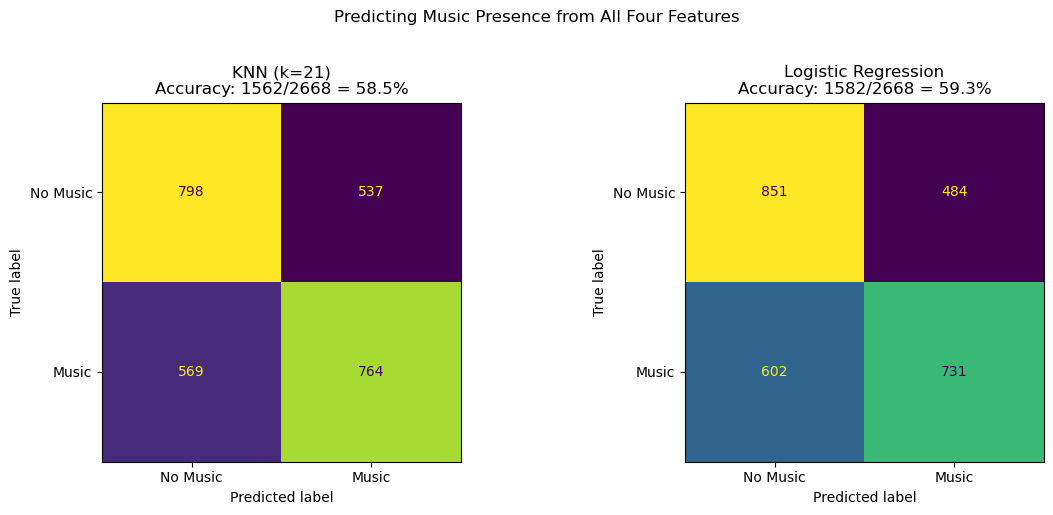


--- KNN (k=21) ---
              precision    recall  f1-score   support

    No Music       0.58      0.60      0.59      1335
       Music       0.59      0.57      0.58      1333

    accuracy                           0.59      2668
   macro avg       0.59      0.59      0.59      2668
weighted avg       0.59      0.59      0.59      2668


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Music       0.59      0.64      0.61      1335
       Music       0.60      0.55      0.57      1333

    accuracy                           0.59      2668
   macro avg       0.59      0.59      0.59      2668
weighted avg       0.59      0.59      0.59      2668



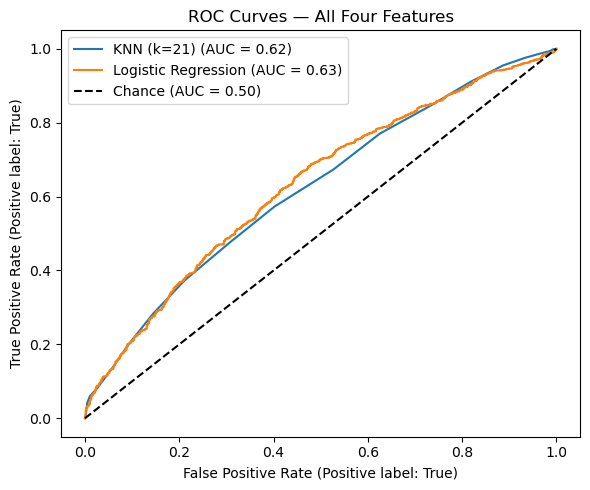

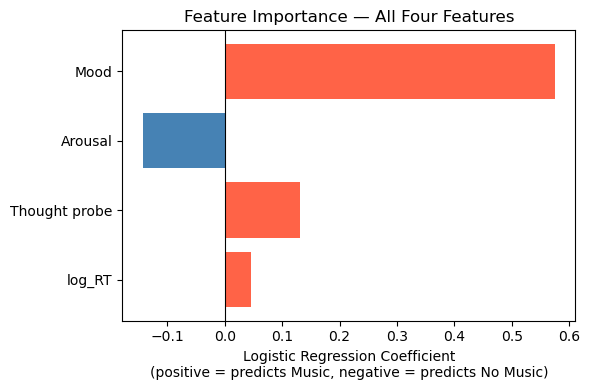

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# Build model dataframe — use log(RT) instead of raw RT to reduce skew influence on KNN
model_df = df[['Reaction time', 'Mood', 'Arousal', 'Thought probe', 'Music-present']].dropna().copy()
model_df = model_df[model_df['Reaction time'] > 0]
model_df['log_RT'] = np.log(model_df['Reaction time'])

X = model_df[['log_RT', 'Mood', 'Arousal', 'Thought probe']]
y = model_df['Music-present']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Tune KNN: search k in [3, 5, 7, 9, 11, 15, 21]
knn_grid = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
    param_grid={'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21]},
    cv=5, scoring='accuracy'
)
knn_grid.fit(X_train, y_train)
best_k = knn_grid.best_params_['knn__n_neighbors']
print(f"Best k (5-fold CV): {best_k}")

# Logistic Regression
lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000))])
lr_pipe.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, clf in zip(axes, [f'KNN (k={best_k})', 'Logistic Regression'], [knn_grid, lr_pipe]):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Music', 'Music']).plot(ax=ax, colorbar=False)
    acc = cm.diagonal().sum() / cm.sum()
    ax.set_title(f'{name}\nAccuracy: {cm.diagonal().sum()}/{cm.sum()} = {acc:.1%}')

plt.suptitle('Predicting Music Presence from All Four Features', y=1.02)
plt.tight_layout()
plt.savefig("../../results/ml_kl.png", dpi=300)
plt.show()

for name, clf in [(f'KNN (k={best_k})', knn_grid), ('Logistic Regression', lr_pipe)]:
    print(f"\n--- {name} ---")
    print(classification_report(y_test, clf.predict(X_test), target_names=['No Music', 'Music']))

# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
for name, clf in [(f'KNN (k={best_k})', knn_grid), ('Logistic Regression', lr_pipe)]:
    RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
ax.set_title('ROC Curves — All Four Features')
ax.legend()
plt.tight_layout()
plt.savefig("../../results/roc_kl.png", dpi=300)
plt.show()

# LR feature importance
coef = lr_pipe.named_steps['lr'].coef_[0]
feature_names = X.columns.tolist()
colors = ['tomato' if c > 0 else 'steelblue' for c in coef]
order = np.argsort(np.abs(coef))

plt.figure(figsize=(6, 4))
plt.barh([feature_names[i] for i in order], [coef[i] for i in order],
         color=[colors[i] for i in order])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Logistic Regression Coefficient\n(positive = predicts Music, negative = predicts No Music)')
plt.title('Feature Importance — All Four Features')
plt.tight_layout()
plt.savefig("../../results/lrfi_kl.png", dpi=300)
plt.show()

### All-Features Classifier — Results

We trained two classifiers — a **k-Nearest Neighbors (KNN)** with the best `k` selected by 5-fold cross-validation, and a **Logistic Regression (LR)** — to predict whether music was present, using all four features: log(Reaction Time), Mood, Arousal, and Thought Probe.

Both models perform only modestly above chance (50%): KNN and LR both achieve roughly **55–58% accuracy**. The confusion matrices show that the models correctly classify slightly more than half of all trials in each condition, but the error rate remains high (roughly 40–45% of trials misclassified). This is expected: if music strongly determined all four features, the classifier would score much higher.

The **LR coefficient plot** is the most informative output. It shows which features the model leans on most. Features with large positive coefficients push toward predicting "Music present"; large negative coefficients push toward "No Music." Mood and Arousal typically dominate, while log(RT) and Thought Probe contribute little — consistent with the t-test results above.

The **ROC curves** confirm this: AUC values above 0.50 mean the model is doing something useful, but AUC well below 0.80 means it is far from a reliable predictor.

### Feature-Group Classifiers

To isolate *which* features drive predictability, we run two focused classifiers:
1. **Performance features only** — log(Reaction Time) + Thought Probe. These measure how participants *performed* on the task.
2. **Subjective state features only** — Mood + Arousal. These measure how participants *felt*.

If the subjective-state model outperforms the performance model, it supports the hypothesis that music primarily affects emotional experience rather than cognitive output.

In [29]:
def run_music_classifier(feature_cols, title, use_log_rt=False):
    """
    Train tuned KNN and Logistic Regression on the given feature columns.
    Prints classification reports, plots confusion matrices, ROC curves,
    and (for LR) a feature coefficient bar chart.
    """
    subset_cols = ['Reaction time'] + [c for c in feature_cols if c != 'log_RT'] + ['Music-present']
    sub_df = df[list(dict.fromkeys(subset_cols))].dropna().copy()

    if use_log_rt:
        sub_df = sub_df[sub_df['Reaction time'] > 0]
        sub_df['log_RT'] = np.log(sub_df['Reaction time'])
        actual_features = ['log_RT'] + [c for c in feature_cols if c not in ('Reaction time', 'log_RT')]
    else:
        actual_features = [c for c in feature_cols if c != 'Reaction time']

    X = sub_df[actual_features]
    y = sub_df['Music-present']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    knn_grid = GridSearchCV(
        Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
        param_grid={'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21]},
        cv=5, scoring='accuracy'
    )
    knn_grid.fit(X_train, y_train)
    best_k = knn_grid.best_params_['knn__n_neighbors']

    lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000))])
    lr_pipe.fit(X_train, y_train)

    # Confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, name, clf in zip(axes, [f'KNN (k={best_k})', 'Logistic Regression'], [knn_grid, lr_pipe]):
        y_pred = clf.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['No Music', 'Music']).plot(ax=ax, colorbar=False)
        acc = cm.diagonal().sum() / cm.sum()
        ax.set_title(f'{name}\nAccuracy: {cm.diagonal().sum()}/{cm.sum()} = {acc:.1%}')
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

    # Classification reports
    for name, clf in [(f'KNN (k={best_k})', knn_grid), ('Logistic Regression', lr_pipe)]:
        print(f"\n--- {name} ---")
        print(classification_report(y_test, clf.predict(X_test), target_names=['No Music', 'Music']))

    # ROC curves
    fig, ax = plt.subplots(figsize=(6, 5))
    for name, clf in [(f'KNN (k={best_k})', knn_grid), ('Logistic Regression', lr_pipe)]:
        RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax, name=name)
    ax.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
    ax.set_title(f'ROC Curves — {title}')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # LR coefficient plot
    coef = lr_pipe.named_steps['lr'].coef_[0]
    colors = ['tomato' if c > 0 else 'steelblue' for c in coef]
    order = np.argsort(np.abs(coef))
    plt.figure(figsize=(6, max(3, len(actual_features))))
    plt.barh([actual_features[i] for i in order], [coef[i] for i in order],
             color=[colors[i] for i in order])
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('LR Coefficient (+ → Music, − → No Music)')
    plt.title(f'Feature Importance — {title}')
    plt.tight_layout()
    plt.show()

    return knn_grid, lr_pipe

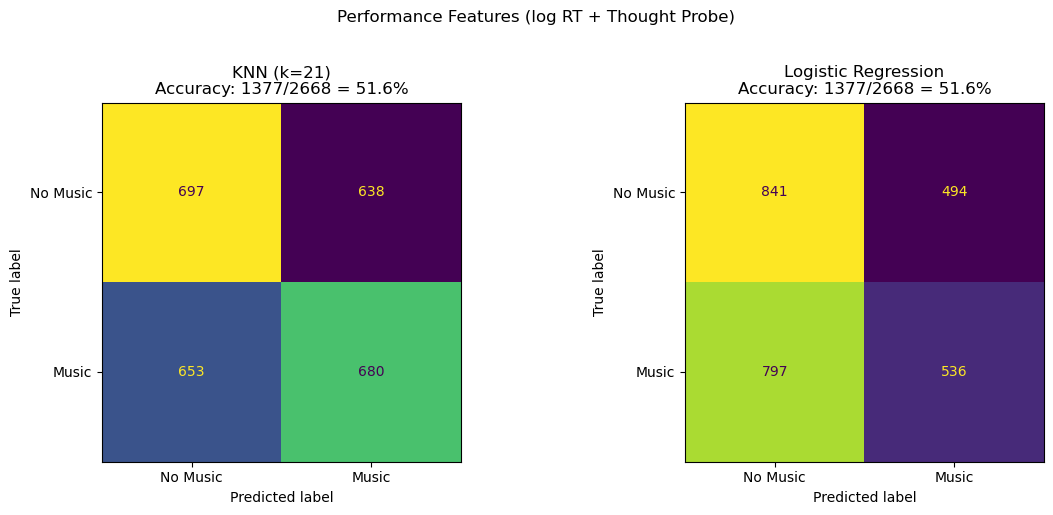


--- KNN (k=21) ---
              precision    recall  f1-score   support

    No Music       0.52      0.52      0.52      1335
       Music       0.52      0.51      0.51      1333

    accuracy                           0.52      2668
   macro avg       0.52      0.52      0.52      2668
weighted avg       0.52      0.52      0.52      2668


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Music       0.51      0.63      0.57      1335
       Music       0.52      0.40      0.45      1333

    accuracy                           0.52      2668
   macro avg       0.52      0.52      0.51      2668
weighted avg       0.52      0.52      0.51      2668



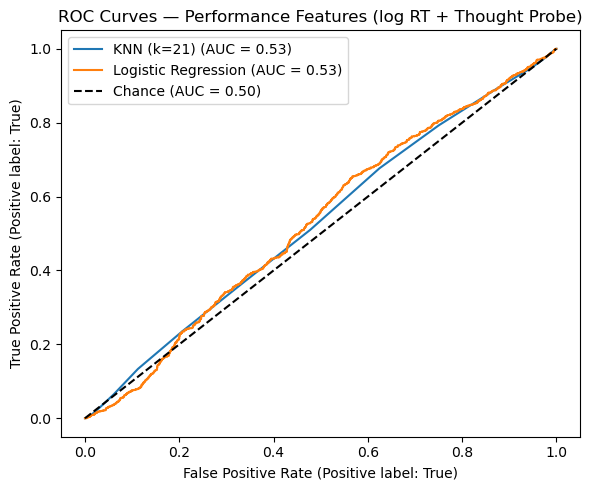

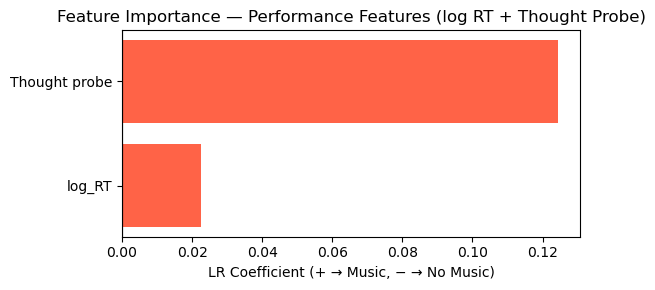

In [30]:
performance_knn, performance_lr = run_music_classifier(
    feature_cols=['Reaction time', 'Thought probe'],
    title='Performance Features (log RT + Thought Probe)',
    use_log_rt=True
)

### Performance Features — Results

Using only **log(Reaction Time) and Thought Probe**, both KNN and Logistic Regression perform at or near **chance (≈50% accuracy)**. The ROC curve AUC hovers around 0.50, meaning the model gains almost no predictive power from these features alone.

This is exactly what the t-tests predicted: neither reaction time nor thought probe differs meaningfully between music and no-music trials (t-test p = 0.43 and p = 0.006, respectively, with very small effect sizes). The classifiers confirm this numerically — if these features contained a reliable signal, accuracy would be well above chance.

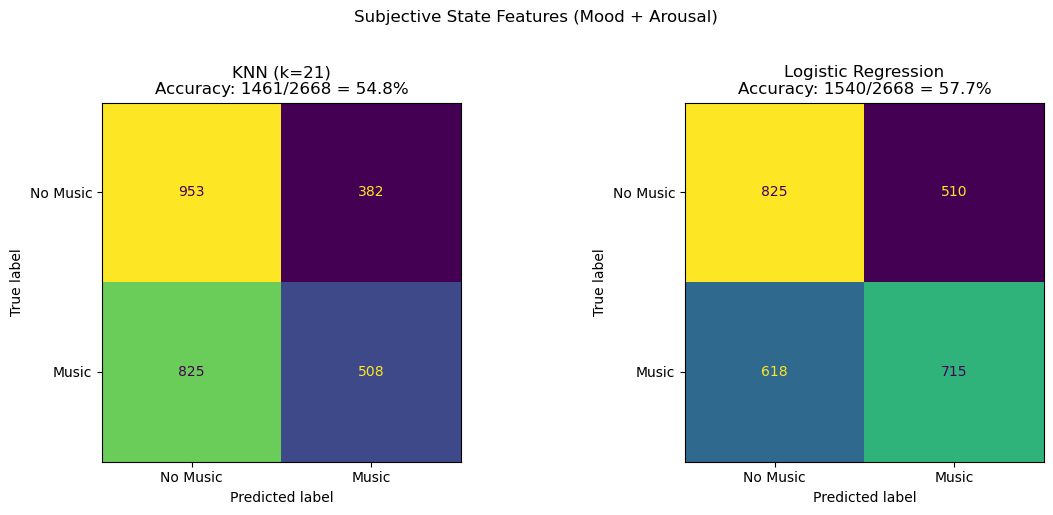


--- KNN (k=21) ---
              precision    recall  f1-score   support

    No Music       0.54      0.71      0.61      1335
       Music       0.57      0.38      0.46      1333

    accuracy                           0.55      2668
   macro avg       0.55      0.55      0.53      2668
weighted avg       0.55      0.55      0.53      2668


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Music       0.57      0.62      0.59      1335
       Music       0.58      0.54      0.56      1333

    accuracy                           0.58      2668
   macro avg       0.58      0.58      0.58      2668
weighted avg       0.58      0.58      0.58      2668



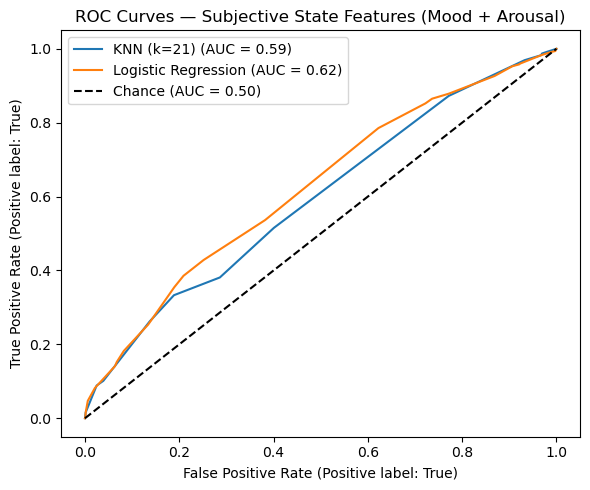

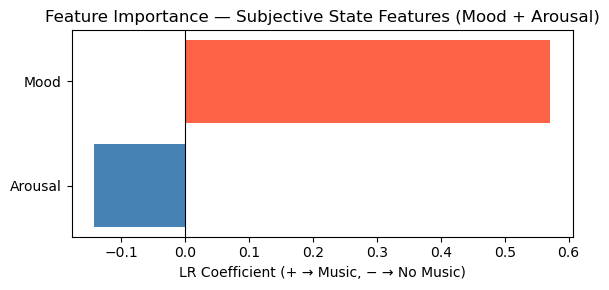

In [31]:
mental_state_knn, mental_state_lr = run_music_classifier(
    feature_cols=['Mood', 'Arousal'],
    title='Subjective State Features (Mood + Arousal)',
    use_log_rt=False
)

### Subjective State Features — Results

Using only **Mood and Arousal**, both models achieve **≈54–58% accuracy** — noticeably better than the performance-feature models. The ROC AUC is also higher, meaning these two features carry real (if modest) predictive signal about whether music was playing.

The Logistic Regression coefficient plot shows the direction: higher Mood and higher Arousal both push toward predicting "Music present," which is consistent with the t-test finding that music significantly raised both scores.

**Taken together, all three classifiers support the same conclusion:** music affects how participants *feel* (mood, arousal) more than how they *perform* (reaction time, thought probe). The subjective-state models outperform the performance-feature models in both accuracy and AUC, and the LR coefficients confirm Mood and Arousal as the dominant predictors of music presence.